In [7]:
#source TFAvenv/bin/activate (launching and exiting the virtual environment containing the required modules, stored in the working directory)
#TFAvenv/bin/python your_script.py - for running a script in the virtual environment
#source deactivate

#import all the libraries needed
from import_dep import *
import importlib

# import my functions stored in the file 'functions' which can then be called with functions.function_name()
from SMU import SMU
import SMU_functions
importlib.reload(SMU_functions)  # Force reload to get updated function signatures with auto-scaling
from SMU_functions import plot_IV, plot_CV, plot_resistance

# import custom plot style and colorbar functions
import plot_style
importlib.reload(plot_style)  # Force reload to get updated markersize parameter
from plot_style import set_plot_style

# Define the path to the root directory containing all the XRD data
root_SMU = '/Users/horatiocox/Desktop/RUG_postdoc/Experiments/Keithley/DR012'
output_SMU = '/Users/horatiocox/Desktop/RUG_postdoc/Experiments/Keithley/DR012/Output'

### Plotting and Output Variables 
export_data = True # set to True to export the data to a powerpoint presentation and as svg files and export to path_out
fig_format = 'svg' # format of the figure to be saved

powerpoint_string = 'DR012_switching' # string to be added to the powerpoint file name

plot_transparency = True # set to True to make the data plots transparent

# Custom plot style settings with small markersize
# This will now work because plot_style.py respects the markersize parameter
fig_size = set_plot_style(export_data=export_data, use_tex=True, markersize=0.1)

# Alternative: You can also pass markersize directly to each plot function
# plot_IV(..., markersize=0.1)
# plot_CV(..., markersize=0.1) 
# plot_resistance(..., markersize=0.1)

print("Updated SMU functions with auto-scaling current units!")

Updated SMU functions with auto-scaling current units!


In [8]:
# Test the SMU class by loading data
print("Testing SMU class...")

# Create SMU object
smu_DR012 = SMU(root_SMU)

# # Display basic information
# print(f"\nSMU object: {smu_DR012}")
# print(f"CV run numbers: {smu_DR012.cv_run_nums[:10]}...")  # Show first 10
# print(f"IV run numbers: {smu_DR012.iv_run_nums[:10]}...")  # Show first 10

# # Show sample CV data
# if smu_DR012.cv_data:
#     print(f"\nSample CV data (first file):")
#     print(smu_DR012.cv_data[0].head())

# # Show sample IV data  
# if smu_DR012.iv_data:
#     print(f"\nSample IV data (first file):")
#     print(smu_DR012.iv_data[0].head())

Testing SMU class...
Found 425 Excel files
Loaded 16 CV files and 409 IV files
Loaded 16 CV files and 409 IV files


# IV Plotting

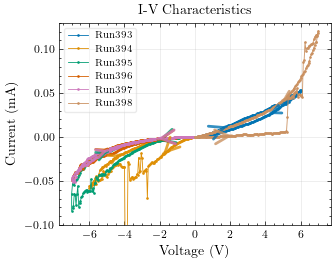

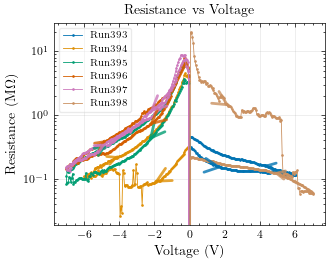

In [9]:
## IV Analysis with Direction Arrows

# Select specific runs for analysis using the built-in methods

#selected_iv_runs = [ 398, 399, 401, 402] 
#selected_iv_runs = [389, 390,392, 404, 398]
selected_iv_runs = [393, 394, 395, 396, 397, 398]

fig_iv = plot_IV([smu_DR012], run_nums=selected_iv_runs, 
                       log_plot=False, plot_arrows=True,
                        y_lim=[-0.10, 0.13],
                        line_width =0.6,
                        markersize=0.9,
                       export_data=export_data, output_SMU=output_SMU,
                       plot_transparency=plot_transparency)

fig_R = plot_resistance([smu_DR012], run_nums=selected_iv_runs, 
                       log_plot=True,
                       line_width =0.6,
                        markersize=0.9,
                       export_data=export_data, plot_arrows = True, output_SMU=output_SMU,
                       plot_transparency=plot_transparency)

# CV Plotting

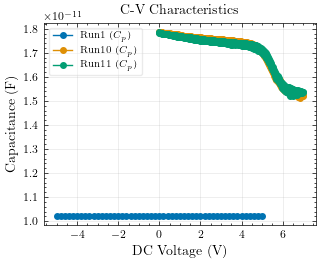


=== Testing Resistance Plot with Arrows ===


In [10]:
## CV Analysis
selected_cv_runs = [1, 10, 11] 

# Use get_cv_data and get_iv_data methods for clean data extraction
cv_data, cv_labels = smu_DR012.get_cv_data(run_nums=selected_cv_runs)

# Plot using the extracted data
fig_cv = plot_CV([smu_DR012], run_nums=selected_cv_runs, log_plot=False,
                 export_data=export_data, output_SMU=output_SMU,
                 plot_transparency=plot_transparency)

## Resistance Analysis with Arrows
print("\n=== Testing Resistance Plot with Arrows ===")
selected_resistance_runs = [1, 11]  # Fewer runs for clearer visualization


=== Testing x_lim masking with auto y-scaling ===
1. IV plot with x_lim=[0, 5] - y-axis should auto-scale to data in this range


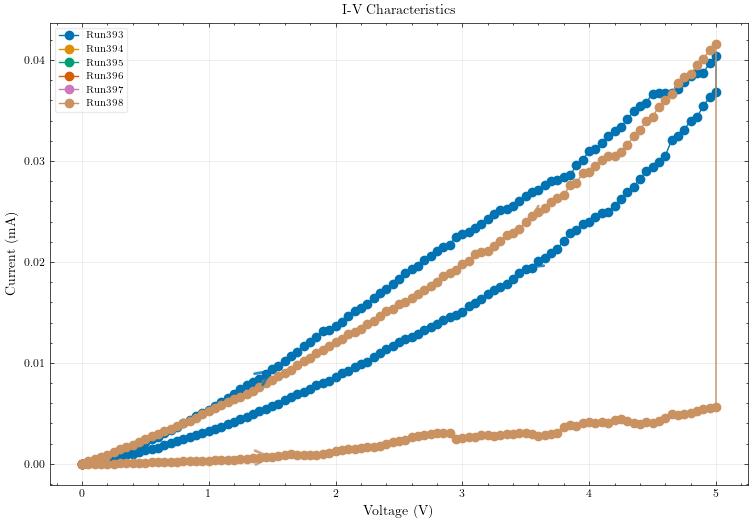

2. Resistance plot with x_lim=[-2, 2] - y-axis should auto-scale to resistance in this range


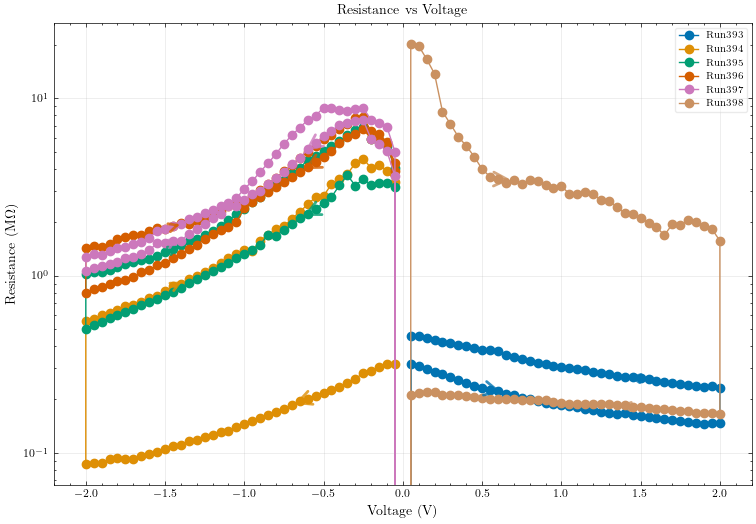

Now y-axis automatically scales to show only the data within the x_lim range!


In [11]:
## Testing x_lim Data Masking with Auto Y-scaling

print("=== Testing x_lim masking with auto y-scaling ===")

# Test 1: IV plot with x_lim masking (y should auto-scale to visible data)
print("1. IV plot with x_lim=[0, 5] - y-axis should auto-scale to data in this range")
fig_iv_masked = plot_IV([smu_DR012], run_nums=selected_iv_runs, 
                       x_lim=[0, 5],  # Only show 0 to 5V range - y will auto-scale
                       log_plot=False, plot_arrows=True,
                       export_data=False, output_SMU=output_SMU)

# Test 2: Resistance plot with x_lim masking
print("2. Resistance plot with x_lim=[-2, 2] - y-axis should auto-scale to resistance in this range")
fig_R_masked = plot_resistance([smu_DR012], run_nums=selected_iv_runs, 
                              x_lim=[-2, 2],  # Focus on -2V to +2V - y will auto-scale
                              log_plot=True, plot_arrows=True,
                              export_data=False, output_SMU=output_SMU)

print("Now y-axis automatically scales to show only the data within the x_lim range!")

### AFM Linescan


AFM data loaded successfully!
Data shape: (498, 12)

Data ranges:
Linescan 1 - X: 0.00 to 4.86 μm, Y: -0.41 to 0.57 nm
Linescan 2 - X: 0.00 to 4.86 μm, Y: -0.36 to 0.41 nm
Linescan 3 - X: 0.00 to 4.86 μm, Y: -0.39 to 0.38 nm

AFM plot saved to: /Users/horatiocox/Desktop/RUG_postdoc/Experiments/AFM/Cypher/LSO_BSO_8a_tt2/linescan/AFM_multiple_linescans.pdf

AFM plot saved to: /Users/horatiocox/Desktop/RUG_postdoc/Experiments/AFM/Cypher/LSO_BSO_8a_tt2/linescan/AFM_multiple_linescans.pdf


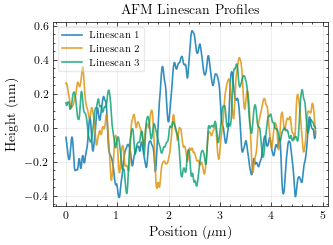


=== AFM Linescan Statistics ===

Linescan 1:
  Mean height: -0.00 nm
  Height std: 0.24 nm
  Peak-to-valley: 0.98 nm
  Scan length: 4.86 μm

Linescan 2:
  Mean height: -0.00 nm
  Height std: 0.16 nm
  Peak-to-valley: 0.77 nm
  Scan length: 4.86 μm

Linescan 3:
  Mean height: -0.00 nm
  Height std: 0.15 nm
  Peak-to-valley: 0.76 nm
  Scan length: 4.86 μm

Overall Statistics (all linescans):
  Mean height: -0.00 nm
  Height std: 0.19 nm
  Global peak-to-valley: 0.98 nm


In [16]:
## AFM Linescan Analysis - Multiple Linescans

# Path to AFM linescan data
path = '/Users/horatiocox/Desktop/RUG_postdoc/Experiments/AFM/Cypher/LSO_BSO_8a_tt2/linescan/2'
output_linescan = '/Users/horatiocox/Desktop/RUG_postdoc/Experiments/AFM/Cypher/LSO_BSO_8a_tt2/linescan'
fig_format = 'pdf'
try:
    # Import AFM linescan data with all 6 columns
    # Columns 1-2: first linescan (x1, y1)
    # Columns 3-4: second linescan (x2, y2) 
    # Columns 5-6: third linescan (x3, y3)
    import re
    
    # Read all 6 columns
    afm_data = pd.read_csv(path, sep=r'\s+', header=None, 
                          names=['x1_m', 'y1_m', 'x2_m', 'y2_m', 'x3_m', 'y3_m'], 
                          engine='python')
    
    # Ensure all data is numeric and handle any string/mixed data
    for col in afm_data.columns:
        afm_data[col] = pd.to_numeric(afm_data[col], errors='coerce')
    
    # Remove any rows with NaN values
    afm_data = afm_data.dropna()
    
    # Convert from meters to more convenient units for all linescans
    # Linescan 1
    afm_data['x1_um'] = afm_data['x1_m'] * 1e6  # Convert to micrometers
    afm_data['y1_nm'] = afm_data['y1_m'] * 1e9  # Convert to nanometers
    
    # Linescan 2  
    afm_data['x2_um'] = afm_data['x2_m'] * 1e6
    afm_data['y2_nm'] = afm_data['y2_m'] * 1e9
    
    # Linescan 3
    afm_data['x3_um'] = afm_data['x3_m'] * 1e6
    afm_data['y3_nm'] = afm_data['y3_m'] * 1e9
    
    print(f"AFM data loaded successfully!")
    print(f"Data shape: {afm_data.shape}")
    print("\nData ranges:")
    print(f"Linescan 1 - X: {afm_data['x1_um'].min():.2f} to {afm_data['x1_um'].max():.2f} μm, Y: {afm_data['y1_nm'].min():.2f} to {afm_data['y1_nm'].max():.2f} nm")
    print(f"Linescan 2 - X: {afm_data['x2_um'].min():.2f} to {afm_data['x2_um'].max():.2f} μm, Y: {afm_data['y2_nm'].min():.2f} to {afm_data['y2_nm'].max():.2f} nm")
    print(f"Linescan 3 - X: {afm_data['x3_um'].min():.2f} to {afm_data['x3_um'].max():.2f} μm, Y: {afm_data['y3_nm'].min():.2f} to {afm_data['y3_nm'].max():.2f} nm")
    
    # Create AFM linescan plot with all three linescans
    fig, ax = plt.subplots(figsize=(fig_size[0], fig_size[1]))
    
    # Define colors for the three linescans
    colors = ['blue', 'red', 'green']
    labels = ['Linescan 1', 'Linescan 2', 'Linescan 3']
    
    # Plot all three linescans
    ax.plot(afm_data['x1_um'], afm_data['y1_nm'], 
            linewidth=1.2, 
            alpha=0.8 if plot_transparency else 1.0,
            label=labels[0])
    
    ax.plot(afm_data['x2_um'], afm_data['y2_nm'], 
            linewidth=1.2, 
            alpha=0.8 if plot_transparency else 1.0,
            label=labels[1])
    
    ax.plot(afm_data['x3_um'], afm_data['y3_nm'], 
            linewidth=1.2, 
            alpha=0.8 if plot_transparency else 1.0,
            label=labels[2])
    
    # Set labels and title
    ax.set_xlabel(r'Position ($\mu$m)')
    ax.set_ylabel(r'Height (nm)')
    ax.set_title(r'AFM Linescan Profiles')
    
    # Add legend to distinguish the linescans
    ax.legend()
    
    # Add grid for better readability
    ax.grid(True, alpha=0.3)
    
    # Apply plot styling
    plt.tight_layout()
    
    # Export if requested
    if export_data:
        # Create output filename
        output_filename = f"AFM_multiple_linescans.{fig_format}"
        output_path = os.path.join(output_linescan, output_filename)
        
        # Save figure
        fig.savefig(output_path, dpi=600, bbox_inches='tight', 
                   transparent=plot_transparency, format=fig_format)
        print(f"\nAFM plot saved to: {output_path}")
    
    plt.show()
    
    # Display data statistics for all linescans
    print(f"\n=== AFM Linescan Statistics ===")
    
    for i, suffix in enumerate(['1', '2', '3'], 1):
        y_col = f'y{suffix}_nm'
        x_col = f'x{suffix}_um'
        print(f"\nLinescan {i}:")
        print(f"  Mean height: {afm_data[y_col].mean():.2f} nm")
        print(f"  Height std: {afm_data[y_col].std():.2f} nm")
        print(f"  Peak-to-valley: {afm_data[y_col].max() - afm_data[y_col].min():.2f} nm")
        print(f"  Scan length: {afm_data[x_col].max() - afm_data[x_col].min():.2f} μm")
    
    # Overall statistics
    all_heights = pd.concat([afm_data['y1_nm'], afm_data['y2_nm'], afm_data['y3_nm']])
    print(f"\nOverall Statistics (all linescans):")
    print(f"  Mean height: {all_heights.mean():.2f} nm")
    print(f"  Height std: {all_heights.std():.2f} nm")
    print(f"  Global peak-to-valley: {all_heights.max() - all_heights.min():.2f} nm")
    
except FileNotFoundError:
    print(f"Error: Could not find file at {path}")
    print("Please check the file path and try again.")
except Exception as e:
    print(f"Error loading AFM data: {e}")
    print("Please check the file format - expecting 6 columns (x1,y1,x2,y2,x3,y3 in meters)")
    print("\nTrying alternative file reading methods...")
    
    # Alternative reading method
    try:
        with open(path, 'r') as f:
            lines = f.readlines()[:10]  # Show first 10 lines
            print("First few lines of the file:")
            for i, line in enumerate(lines, 1):
                print(f"Line {i}: {repr(line)}")
    except:
        print("Could not read file content for debugging.")